# 2D cond 1D — Behavior Under Infeasible / Adversarial Targets

`Exp_2D_cond_1D.ipynb` builds its target `G(Y)` by slicing the true joint `P(X,Y)` at a chosen `x_star`, so an exact match (`L(x_star) = 0`) is guaranteed by construction. This notebook studies the complementary case: **target distributions `G` that do not correspond exactly to any single conditional `P(Y|X=x)`**, and checks how MLGD and MLGD-F behave when exact matching is impossible.

It reuses the same pretrained checkpoints, joint GMM, and optimization code (`Optimization.optimize_LGD`) as `Exp_2D_cond_1D.ipynb` — nothing in `src/` is modified. The only change is *what target `G` we hand to the optimizer*: `optimize_LGD` already treats `(mog_means, mog_variances, weights)` as a free-standing target fully decoupled from the joint, so any GMM can be passed in.

### An analytic oracle for grading
Because `dim(x) = 1` here, the reachable set `{P(Y|X=x) : x in R}` is a 1-D curve through distribution space, and every point on it is closed-form Gaussian (`compute_conditionals` + `compute_alpha`). So for **any** target `G` — feasible or not — we can grid-search `x` directly on the analytic conditional and compute
```
L*(G) = min_x  gmm_l2_distance( P(Y|X=x), G )
```
in milliseconds, with no diffusion model involved. `L*` is the ground truth MLGD / MLGD-F are graded against below. On a feasible target `L* = 0`, which we use as a sanity check.

### Scenarios
| id | name | construction | intent |
|---|---|---|---|
| S0 | feasible baseline | true conditional at `x_star=-5` (same as main experiment) | sanity check, `L*` should be ≈0 |
| S1 | soft / near-feasible | true conditional at `x_star=-5`, component means shifted by `+SHIFT_S1` | mild, controllable infeasibility |
| S2 | structural / bimodal | `0.5 * P(Y\|X=x1) + 0.5 * P(Y\|X=x2)` for well-separated `x1, x2` | target requires two conditionals at once |
| S3 | hard / out-of-support | Gaussian centered far outside the range `Y` ever takes under the joint | tests graceful degradation vs. pathological behavior at the extreme |


In [27]:
import os
# ============================================================
# CONFIG
# Reuses the SAME joint GMM + checkpoints as EXPERIMENT_NAME below (feasible-target notebook).
# Results from THIS notebook are written to a separate results dir so nothing is overwritten.
# ============================================================
BASE_EXPERIMENT_NAME = "2D_cond_1D"          # source of GMM params + model checkpoints (unchanged)
EXPERIMENT_NAME       = "2D_cond_1D_infeasible"   # where THIS notebook writes its own results
GLOBAL_SEED           = 42

BASE_DIR        = os.path.normpath(os.path.join(os.getcwd(), ".."))
PARAMS_DIR      = f"{BASE_DIR}/params"
CHECKPOINT_DIR  = f"{BASE_DIR}/checkpoints/{BASE_EXPERIMENT_NAME}"   # reuse existing checkpoints, no retraining
RESULTS_DIR     = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture (must match the checkpoints being loaded)
NBLOCKS, NUNITS       = 3, 128
NBLOCKS_CM, NUNITS_CM = 3, 128
DIFFUSION_STEPS       = 100
CONDITION_ON          = 1   # dim(x)=1, dim(y)=1

# Optimization (kept modest: 3 scenarios x 2 methods x N_ATTEMP_OPTIM runs)
N_ATTEMP_OPTIM             = 25
NSAMPLES_IN_OPTIM_FOR_MMD  = 250
NUM_X_T_LGD                = 3
NUM_X_T_LGD_CM              = 3

# Scenario knobs
S1_MEAN_SHIFT = 1.0     # S1: shift true-conditional component means by this much
S2_X1, S2_X2  = -5.0, 5.0   # S2: the two x-locations mixed together
S2_WEIGHT     = 0.5         # S2: mixture weight on the x1 conditional
S3_MEAN       = 20.0    # S3: target mean, well outside the joint's Y-range (~[-8, 8])
S3_VAR        = 0.3     # S3: target variance (typical of a single component)

# Oracle grid search
ORACLE_GRID_LO, ORACLE_GRID_HI, ORACLE_GRID_N = -15.0, 30.0, 900
ORACLE_REFINE_N = 400


In [28]:
import os, sys
src_path = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f"src path on sys.path: {src_path}")


src path on sys.path: /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src


In [3]:
# Install dependencies if needed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flow_matching", "POT", "-q"])


0

In [4]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
from LossFunctions import MMDLoss, RBF

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Imports done.")


Imports done.


/sci/labs/orzuk/ori_m/dps_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)


ENVIRONMENT INFO
  timestamp: 2026-07-28T10:11:41.858686
  torch_version: 2.5.1+cu121
  cuda_available: True
  cuda_version: 12.1
  device_name: NVIDIA L4
  packages: {'torch': '2.5.1+cu121', 'numpy': '2.4.3', 'flow_matching': '1.0.10', 'POT': '0.9.6.post1', 'matplotlib': '3.10.8', 'pandas': '3.0.2', 'tqdm': '4.67.3'}
  packages:


In [6]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


[Seed] All random seeds set to 42
Using device: cuda


## Load the joint GMM (same one `Exp_2D_cond_1D.ipynb` uses)

In [7]:
loaded = experiment_utils.load_gmm_params(PARAMS_DIR, BASE_EXPERIMENT_NAME)
if loaded is None:
    raise FileNotFoundError(
        f"Could not find saved GMM params for '{BASE_EXPERIMENT_NAME}' in {PARAMS_DIR}. "
        "Run Exp_2D_cond_1D.ipynb at least once first (it generates and saves the joint GMM)."
    )
mu_list, Sigma_list, alpha, mog_means_true, mog_variances_true, weights_true, x_star = loaded
mu_list    = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha      = alpha.float()
print(f"Loaded joint GMM with {len(mu_list)} components. Reference x_star = {x_star.item()}")


[GMM] Parameters loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/params/2D_cond_1D_gmm_params.pt
Loaded joint GMM with 11 components. Reference x_star = -5


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/experiment_utils.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


## Load pretrained models (no retraining — reuses `2D_cond_1D` checkpoints)

In [8]:
B_dummy = torch.cat([m.view(1, -1) for m in mu_list], dim=0)
nfeatures = B_dummy.shape[1] - CONDITION_ON

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON, nunits=NUNITS_CM, depth=NBLOCKS_CM
)
ok_cm = experiment_utils.load_checkpoint_with_hf_fallback(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_cm, "Failed to load the CM (MLGD-F) checkpoint — run Exp_2D_cond_1D.ipynb once first."

model_cond = Diffusion.DiffusionModel(
    nfeatures=B_dummy.shape[1], nblocks=NBLOCKS, nunits=NUNITS,
    condition=True, condition_on=CONDITION_ON, diffusion_steps=DIFFUSION_STEPS
)
ok_cond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_cond, "Diffusion_cond", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_cond, "Failed to load the conditional diffusion (MLGD) checkpoint."

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)
ok_uncond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_uncond, "Failed to load the unconditional diffusion checkpoint."
print("All checkpoints loaded.")


[Checkpoint] CM loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/experiment_utils.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path

[Checkpoint] Diffusion_cond loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt
[Checkpoint] Diffusion_uncond loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt
All checkpoints loaded.


## Build the infeasible / adversarial targets (S1, S2, S3)

Each target is just a `(means, variances, weights)` GMM over `Y` — exactly the same object type `Exp_2D_cond_1D.ipynb` builds from a single `x_star`. `optimize_LGD` doesn't know or care where it came from.

In [9]:
def true_conditional_at(x_val, threshold=0.01):
    """Analytic P(Y|X=x_val) for the joint GMM, filtered/normalized (same as main notebook)."""
    x = torch.tensor([float(x_val)])
    mu_c, S_c = dist_utils.compute_conditionals(mu_list, Sigma_list, x)
    w_c = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x)
    return dist_utils.filter_and_normalize(mu_c, S_c, w_c, threshold=threshold)

def scenario_loss(x_val, tgt_mu, tgt_S, tgt_w):
    """Exact L2-GMM loss L(x) = || P(Y|X=x) - G ||^2 at a scalar x, closed form (no sampling)."""
    mu_c, S_c, w_c = true_conditional_at(x_val)
    return dist_utils.gmm_l2_distance(mu_c, S_c, w_c, tgt_mu, tgt_S, tgt_w)

def oracle_grid_search(tgt_mu, tgt_S, tgt_w,
                        lo=ORACLE_GRID_LO, hi=ORACLE_GRID_HI,
                        n=ORACLE_GRID_N, n_refine=ORACLE_REFINE_N):
    """L*(G) = min_x L(x), found by dense grid search then a local refine pass."""
    xs = torch.linspace(lo, hi, n)
    losses = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs])
    i = int(losses.argmin())
    lo2 = xs[max(i - 2, 0)].item()
    hi2 = xs[min(i + 2, n - 1)].item()
    xs2 = torch.linspace(lo2, hi2, n_refine)
    losses2 = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs2])
    j = int(losses2.argmin())
    return xs2[j].item(), losses2[j].item(), (xs, losses)   # also return the full curve for plotting


In [10]:
scenarios = {}

# --- S0: feasible baseline (sanity check — L* should be ~0 at x_star) ---
mu0, S0_, w0 = true_conditional_at(x_star.item())
scenarios["S0_feasible_baseline"] = dict(mog_means=mu0, mog_variances=S0_, weights=w0)

# --- S1: soft / near-feasible — true conditional at x_star, component means shifted ---
mu1, S1_, w1 = true_conditional_at(x_star.item())
mu1 = mu1 + S1_MEAN_SHIFT
scenarios["S1_soft_shift"] = dict(mog_means=mu1, mog_variances=S1_, weights=w1)

# --- S2: structural / bimodal — 0.5/0.5 mixture of two well-separated conditionals ---
mu_a, Sa, wa = true_conditional_at(S2_X1)
mu_b, Sb, wb = true_conditional_at(S2_X2)
mu2 = torch.cat([mu_a, mu_b], dim=0)
S2_ = torch.cat([Sa, Sb], dim=0)
w2  = torch.cat([S2_WEIGHT * wa / wa.sum(), (1 - S2_WEIGHT) * wb / wb.sum()], dim=0)
scenarios["S2_bimodal_mixture"] = dict(mog_means=mu2, mog_variances=S2_, weights=w2)

# --- S3: hard / out-of-support — Gaussian far outside the joint's Y-range ---
mu3 = torch.tensor([[S3_MEAN]])
S3_ = torch.tensor([[[S3_VAR]]])
w3  = torch.tensor([1.0])
scenarios["S3_hard_out_of_support"] = dict(mog_means=mu3, mog_variances=S3_, weights=w3)

# --- Oracle for every scenario ---
for name, sc in scenarios.items():
    x_oracle, L_star, curve = oracle_grid_search(sc["mog_means"], sc["mog_variances"], sc["weights"])
    sc["x_oracle"], sc["L_star"], sc["curve"] = x_oracle, L_star, curve
    print(f"{name:26s} | x_oracle={x_oracle:7.3f} | L*={L_star:.6f}")


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/dist_utils.py:356: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff


S0_feasible_baseline       | x_oracle= -5.000 | L*=0.000000
S1_soft_shift              | x_oracle= -3.567 | L*=0.190198
S2_bimodal_mixture         | x_oracle=  5.934 | L*=0.177862
S3_hard_out_of_support     | x_oracle= -0.984 | L*=0.739074


## Loss curve `L(x)` per scenario

Since `L(x)` is closed-form, we can plot the *entire* loss landscape over `x` for each target — this is the cheapest possible diagnostic for whether MLGD / MLGD-F land near the true global minimum or get stuck somewhere else.

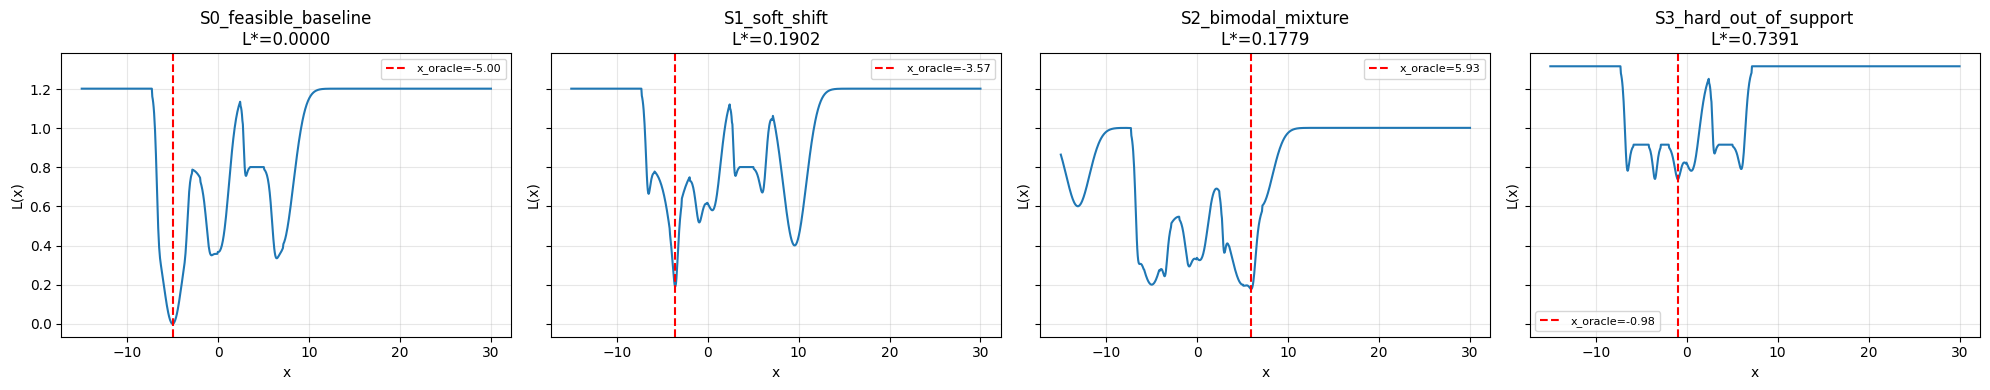

In [11]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 4), sharey=True)
for ax, (name, sc) in zip(axes, scenarios.items()):
    xs, losses = sc["curve"]
    ax.plot(xs.numpy(), losses.numpy(), lw=1.5)
    ax.axvline(sc["x_oracle"], color="red", ls="--", label=f"x_oracle={sc['x_oracle']:.2f}")
    ax.set_title(f"{name}\nL*={sc['L_star']:.4f}")
    ax.set_xlabel("x"); ax.set_ylabel("L(x)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Optimize under each target: MLGD vs MLGD-F

Identical call to `Optimization.optimize_LGD` as the main notebook — only the `(mog_means, mog_variances, weights)` argument changes per scenario.

In [12]:
def run_method(model_cond_obj, CM_flag, num_x_t, sc, n_attempts):
    x_preds, l2_gmm_list, l2_xstar_list, l2_xoracle_list, times, final_losses = [], [], [], [], [], []
    for i in trange(n_attempts, leave=False):
        run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)   # same seed for both methods, attempt i
        t0 = time.time()
        best_x_t, _, final_loss = Optimization.optimize_LGD(
            model_uncond, model_cond_obj,
            sc["mog_means"], sc["mog_variances"], sc["weights"],
            mu_list, Sigma_list, alpha,
            nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
            CM=CM_flag, FLAG=False, num_x_t=num_x_t,
        )
        times.append(time.time() - t0)
        final_losses.append(final_loss)
        x_preds.append(best_x_t)

        x_pred = best_x_t.float().view(-1).cpu()
        mu_p, S_p, w_p = true_conditional_at(x_pred.item())
        l2_gmm = dist_utils.gmm_l2_distance(mu_p, S_p, w_p, sc["mog_means"], sc["mog_variances"], sc["weights"])

        l2_gmm_list.append(l2_gmm)
        l2_xstar_list.append((x_pred - x_star.float().cpu()).pow(2).sum().sqrt().item())
        l2_xoracle_list.append(abs(x_pred.item() - sc["x_oracle"]))
    return dict(x_pred=x_preds, l2_gmm=l2_gmm_list, l2_xstar=l2_xstar_list,
                l2_xoracle=l2_xoracle_list, times=times, final_loss=final_losses)

all_results = {}
for name, sc in scenarios.items():
    print(f"\n=== {name} (L*={sc['L_star']:.6f}) ===")
    res_mlgd   = run_method(model_cond, False, NUM_X_T_LGD,    sc, N_ATTEMP_OPTIM)
    res_mlgdf  = run_method(Cos_ConsistencyModeliCT, True, NUM_X_T_LGD_CM, sc, N_ATTEMP_OPTIM)
    all_results[name] = {"MLGD": res_mlgd, "MLGD-F": res_mlgdf}



=== S0_feasible_baseline (L*=0.000000) ===



=== S1_soft_shift (L*=0.190198) ===



=== S3_hard_out_of_support (L*=0.739074) ===


## Results: regret against the oracle

`regret = L(x_pred) - L*` — how far each method lands from the *best achievable* loss, not from zero. On S0 this should match the main notebook's numbers (regret ≈ L2-to-x* result since `L*≈0`); on S1/S2/S3 it isolates optimization quality from target-infeasibility.

In [33]:
def summary_row_regret(method_name, scenario_name, res, L_star, top_k=5):
    l2_gmm     = np.array(res["l2_gmm"])
    regret     = l2_gmm - L_star
    l2_xoracle = np.array(res["l2_xoracle"])
    times      = np.array(res["times"])

    # Top-k selection: rank restarts by the metric being REPORTED (exact L2-GMM), not by the
    # optimizer's own MMD criterion. We checked this explicitly for S2 (bimodal target): MMD and
    # L2-GMM were negatively correlated there (Spearman rho ≈ -0.73/-0.79), because a mode-collapsed
    # restart can look artificially good under finite-sample MMD while being clearly wrong under the
    # exact metric. Selecting by MMD would silently pick the wrong restarts in that regime, so we
    # select by l2_gmm directly to get a fair best-of-N number for every scenario.
    k = min(top_k, len(l2_gmm))
    top_idx = np.argsort(l2_gmm)[:k]

    l2_gmm_top = l2_gmm[top_idx]
    regret_top = regret[top_idx]
    times_top  = times[top_idx]

    return {
        "Scenario":         scenario_name,
        "Method":           method_name,
        "L* (oracle)":      f"{L_star:.4f}",
        "L2-GMM":           f"{l2_gmm.mean():.4f} ± {l2_gmm.std():.4f}",
        "Regret":           f"{regret.mean():.4f} ± {regret.std():.4f}",
        "Time (s)":         f"{times.mean():.2f} ± {times.std():.2f}",
        f"Top-{k} L2-GMM":  f"{l2_gmm_top.mean():.4f} ± {l2_gmm_top.std():.4f}",
        f"Top-{k} Regret":  f"{regret_top.mean():.4f} ± {regret_top.std():.4f}",
        f"Top-{k} Time (s)":f"{times_top.mean():.2f} ± {times_top.std():.2f}",
        "N restarts":       len(l2_gmm),
    }

rows = []
for name, sc in scenarios.items():
    for method in ["MLGD", "MLGD-F"]:
        rows.append(summary_row_regret(method, name, all_results[name][method], sc["L_star"], top_k=5))
df = pd.DataFrame(rows).set_index(["Scenario", "Method"])
display(df)

L* (oracle)           L2-GMM           Regret  \
Scenario               Method                                                 
S0_feasible_baseline   MLGD        0.0000  0.1828 ± 0.3747  0.1828 ± 0.3747   
                       MLGD-F      0.0000  0.0937 ± 0.1618  0.0937 ± 0.1618   
S1_soft_shift          MLGD        0.1902  0.4963 ± 0.2547  0.3061 ± 0.2547   
                       MLGD-F      0.1902  0.4612 ± 0.1103  0.2710 ± 0.1103   
S2_bimodal_mixture     MLGD        0.1779  0.3864 ± 0.1388  0.2085 ± 0.1388   
                       MLGD-F      0.1779  0.4158 ± 0.0728  0.2379 ± 0.0728   
S3_hard_out_of_support MLGD        0.7391  0.9867 ± 0.1669  0.2477 ± 0.1669   
                       MLGD-F      0.7391  0.9223 ± 0.1443  0.1832 ± 0.1443   

                                    Time (s)     Top-5 L2-GMM  \
Scenario               Method                                   
S0_feasible_baseline   MLGD     52.10 ± 1.09  0.0001 ± 0.0001   
                       MLGD-F    6.38 ± 0.19  0.0102 ± 0.0069   
S1_soft_shift          MLGD     52.21 ± 0.53  0.3763 ± 0.0068   
                       MLGD-F    6.34 ± 0.03  0.3683 ± 0.0333   
S2_bimodal_mixture     MLGD     52.24 ± 0.11  0.2661 ± 0.0921   
                       MLGD-F   10.91 ± 2.26  0.3607 ± 0.0431   
S3_hard_out_of_support MLGD    86.61 ± 27.33  0.8976 ± 0.0362   
                       MLGD-F    6.31 ± 0.10  0.8488 ± 0.0719   

                                  Top-5 Regret Top-5 Time (s)  N restarts  
Scenario               Method                                              
S0_feasible_baseline   MLGD    0.0001 ± 0.0001   51.85 ± 0.30          10  
                       MLGD-F  0.0102 ± 0.0069    6.33 ± 0.05          10  
S1_soft_shift          MLGD    0.1861 ± 0.0068   52.47 ± 0.52          10  
                       MLGD-F  0.1781 ± 0.0333    6.33 ± 0.03          10  
S2_bimodal_mixture     MLGD    0.0883 ± 0.0921   52.23 ± 0.05          10  
                       MLGD-F  0.1828 ± 0.0431   10.38 ± 2.75          10  
S3_hard_out_of_support MLGD    0.1585 ± 0.0362  98.21 ± 22.82          10  
                       MLGD-F  0.1097 ± 0.0719    6.35 ± 0.06          10

## Where restarts land relative to the loss landscape

For a genuinely infeasible target (especially S2, the bimodal case) there's no reason to expect restarts to agree. The plot below overlays each restart's recovered `(x_pred, L(x_pred))` directly on the analytic loss curve: do restarts cluster near `x_oracle`, or land in a different, suboptimal basin?


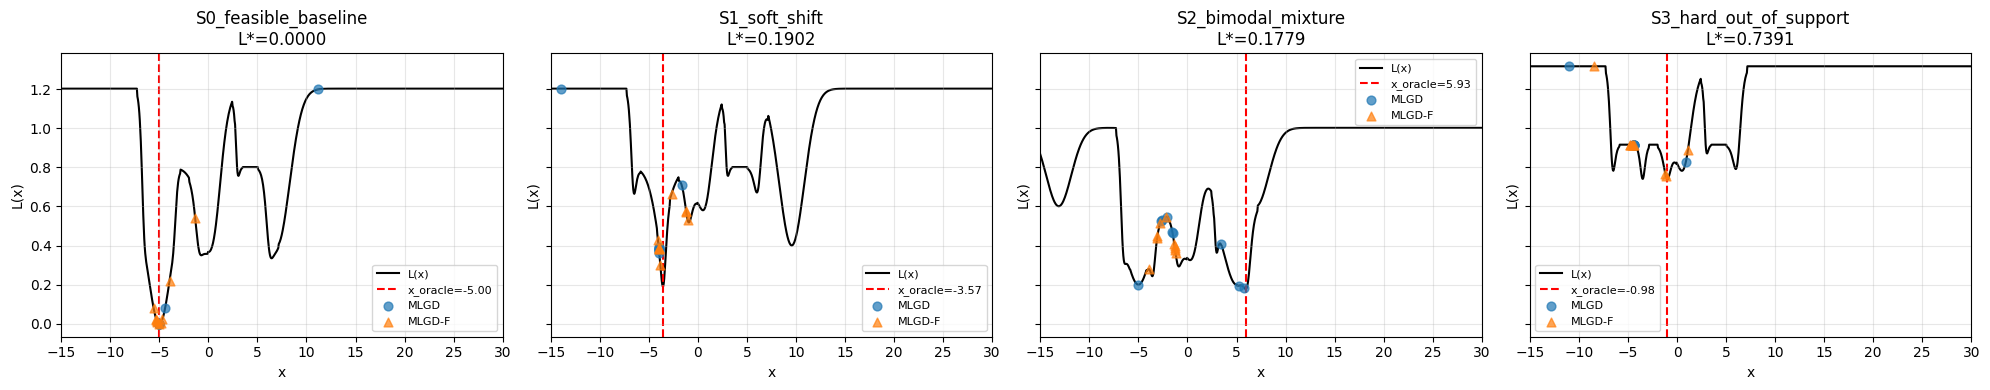

In [19]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 4), sharey=True)
for ax, (name, sc) in zip(axes, scenarios.items()):
    xs, losses = sc["curve"]
    ax.plot(xs.numpy(), losses.numpy(), lw=1.5, color="black", zorder=1, label="L(x)")
    ax.axvline(sc["x_oracle"], color="red", ls="--", zorder=1, label=f"x_oracle={sc['x_oracle']:.2f}")
    x_mlgd  = [xt.float().view(-1).cpu().item() for xt in all_results[name]["MLGD"]["x_pred"]]
    x_mlgdf = [xt.float().view(-1).cpu().item() for xt in all_results[name]["MLGD-F"]["x_pred"]]
    l_mlgd  = all_results[name]["MLGD"]["l2_gmm"]
    l_mlgdf = all_results[name]["MLGD-F"]["l2_gmm"]
    ax.scatter(x_mlgd,  l_mlgd,  s=40, alpha=0.7, zorder=2, label="MLGD")
    ax.scatter(x_mlgdf, l_mlgdf, s=40, alpha=0.7, marker="^", zorder=2, label="MLGD-F")
    ax.set_xlim(xs.min().item(), xs.max().item())
    ax.set_title(f"{name}\nL*={sc['L_star']:.4f}")
    ax.set_xlabel("x"); ax.set_ylabel("L(x)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## MMD (optimization objective) vs. exact L2-GMM (evaluation metric): do they agree?

`optimize_LGD` is guided by a finite-sample MMD estimate; we evaluate with the exact closed-form L2-GMM distance. On an infeasible target the MMD's finite-sample bias may matter more, since there's no exact zero to converge to — check whether ranking by `final_loss` (MMD) still tracks ranking by `l2_gmm` (L2).

In [31]:
from scipy.stats import spearmanr
print(f"{'Scenario':26s} | {'Method':7s} | {'rho':>7s} | {'p-value':>8s} | n")
for name in scenarios:
    for method in ["MLGD", "MLGD-F"]:
        res = all_results[name][method]
        mmd_vals = [fl.item() if hasattr(fl, "item") else fl for fl in res["final_loss"]]
        rho, p = spearmanr(mmd_vals, res["l2_gmm"])
        n = len(mmd_vals)
        sig = "*" if p < 0.05 else " "
        print(f"{name:26s} | {method:7s} | {rho:7.3f} | {p:8.4f} | n={n} {sig}")

Scenario                   | Method  |     rho |  p-value | n
S0_feasible_baseline       | MLGD    |   0.503 |   0.1383 | n=10  
S0_feasible_baseline       | MLGD-F  |   0.079 |   0.8287 | n=10  
S1_soft_shift              | MLGD    |   0.103 |   0.7770 | n=10  
S1_soft_shift              | MLGD-F  |   0.770 |   0.0092 | n=10 *
S2_bimodal_mixture         | MLGD    |  -0.733 |   0.0158 | n=10 *
S2_bimodal_mixture         | MLGD-F  |  -0.794 |   0.0061 | n=10 *
S3_hard_out_of_support     | MLGD    |   0.390 |   0.2658 | n=10  
S3_hard_out_of_support     | MLGD-F  |  -0.218 |   0.5442 | n=10  


## Save results

In [16]:
def to_python(val):
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, "item"):
        return val.item()
    return val

out = {
    "experiment": EXPERIMENT_NAME,
    "base_experiment": BASE_EXPERIMENT_NAME,
    "seed": GLOBAL_SEED,
    "environment": env_info,
    "scenarios": {},
}
for name, sc in scenarios.items():
    out["scenarios"][name] = {
        "x_oracle": sc["x_oracle"],
        "L_star": sc["L_star"],
        "target_means": to_python(sc["mog_means"]),
        "target_variances": to_python(sc["mog_variances"]),
        "target_weights": to_python(sc["weights"]),
        "MLGD": {k: [to_python(v) for v in vs] for k, vs in all_results[name]["MLGD"].items()},
        "MLGD-F": {k: [to_python(v) for v in vs] for k, vs in all_results[name]["MLGD-F"].items()},
    }

path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_results_seed{GLOBAL_SEED}.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2)
print(f"Results saved to {path}")


Results saved to /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/results/2D_cond_1D_infeasible/2D_cond_1D_infeasible_results_seed42.json
